# Figure 3i: ligand-TF-region-gene network (horizontal)

In [1]:
import os

work_dir = "/Users/lulu/Documents/ForJavid/scplus_pipeline"
outs_dir = os.path.join(work_dir, "outs")
tmp_dir = os.path.join(work_dir, "tmp")

In [2]:
import os
import mudata
import pandas as pd

plots_dir = os.path.join(work_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

scplus_mdata = mudata.read_h5mu(os.path.join(outs_dir, "scplusmdata.h5mu"))

ligand_dir = os.path.join(work_dir, "ligand")
ligand_tf_edges = pd.read_csv(os.path.join(ligand_dir, "ligand_tf_edges.csv"))

/Users/lulu/anaconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/lulu/anaconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/lulu/anaconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/lulu/anaconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/lulu/anaconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/lulu/anaconda

## Converting mudata output to old-style SCENIC+ object

In [3]:
from scenicplus.scenicplus_class import mudata_to_scenicplus
scplus_obj = mudata_to_scenicplus(
    mdata = scplus_mdata,
)

/Users/lulu/anaconda3/envs/scenicplus/lib/python3.11/site-packages/scenicplus/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [4]:
from pycisTopic.diff_features import find_highly_variable_features
hvr = find_highly_variable_features(scplus_obj.to_df('ACC').loc[list(set(scplus_obj.uns['eRegulon_metadata']['Region']))], n_top_features=3400, plot = False)
hvg = find_highly_variable_features(scplus_obj.to_df('EXP')[list(set(scplus_obj.uns['eRegulon_metadata']['Gene']))].T, n_top_features=1000, plot = False)

2026-09-01 11:07:10,576 cisTopic     INFO     Calculating mean
2026-09-01 11:07:10,818 cisTopic     INFO     Calculating variance
2026-09-01 11:07:12,663 cisTopic     INFO     Done!
2026-09-01 11:07:13,835 cisTopic     INFO     Calculating mean
2026-09-01 11:07:13,939 cisTopic     INFO     Calculating variance
2026-09-01 11:07:14,244 cisTopic     INFO     Done!


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

## `build_ligand_tf_eregulon_network`

In [5]:
def build_ligand_tf_eregulon_network(tf_subset, eregulon_metadata, ligand_tf_edges,
                                      subset_regions=None, subset_genes=None,
                                      max_targets_per_tf=None):
    """
    Build Cytoscape-ready node/edge tables for a Ligand -> TF -> Region -> Gene network.

    tf_subset: TFs to include -- their eRegulons (TF2Region, Region2Gene) are pulled
        in, together with every ligand edge pointing at them (Ligand2TF).
    subset_regions / subset_genes: optional whitelist to shrink each TF's eRegulon down
        to its highly-variable regions/genes (e.g. the `hvr`/`hvg` computed above),
        same convention as `create_nx_tables` uses for the TF-only network.
    max_targets_per_tf: optional cap -- keep only the top-N Region-Gene edges per TF
        (ranked by `importance_R2G`) to declutter TFs with very large eRegulons.
    """
    er = eregulon_metadata[eregulon_metadata['TF'].isin(tf_subset)].copy()
    if subset_regions is not None:
        er = er[er['Region'].isin(subset_regions)]
    if subset_genes is not None:
        er = er[er['Gene'].isin(subset_genes) | er['Gene'].isin(tf_subset)]
    if max_targets_per_tf is not None:
        er = (er.sort_values('importance_R2G', ascending=False)
                .groupby('TF', group_keys=False)
                .head(max_targets_per_tf))
    lig_edges = ligand_tf_edges[ligand_tf_edges['TF'].isin(tf_subset)].copy()

    # --- edges ---
    lig2tf = lig_edges[['ligand', 'TF', 'fdr_q_value', 'ligand_rank_by_fdr',
                         'edge_evidence', 'near_far_direction']].drop_duplicates()
    lig2tf.columns = ['source', 'target', 'fdr_q_value', 'ligand_rank_by_fdr',
                       'edge_evidence', 'near_far_direction']
    lig2tf['interaction'] = 'Ligand2TF'

    tf2r = er[['TF', 'Region', 'is_extended']].drop_duplicates()
    tf2r.columns = ['source', 'target', 'is_extended']
    tf2r['interaction'] = 'TF2Region'

    r2g = er[['Region', 'Gene', 'importance_R2G', 'rho_R2G']].drop_duplicates()
    r2g.columns = ['source', 'target', 'importance_R2G', 'rho_R2G']
    r2g['interaction'] = 'Region2Gene'

    edges = pd.concat([lig2tf, tf2r, r2g], axis=0, ignore_index=True, sort=False)

    # --- nodes ---
    n_upstream_ligands = lig_edges.groupby('TF')['ligand'].nunique()
    n_target_genes = er.groupby('TF')['Gene'].nunique()
    n_regions = er.groupby('TF')['Region'].nunique()
    tf_nodes = pd.DataFrame({'node': sorted(set(tf_subset))})
    tf_nodes['Node_type'] = 'TF'
    tf_nodes['n_upstream_ligands'] = tf_nodes['node'].map(n_upstream_ligands).fillna(0)
    tf_nodes['n_target_genes'] = tf_nodes['node'].map(n_target_genes).fillna(0)
    tf_nodes['n_regions'] = tf_nodes['node'].map(n_regions).fillna(0)

    n_target_tfs = lig_edges.groupby('ligand')['TF'].nunique()
    ligand_nodes = pd.DataFrame({'node': sorted(lig_edges['ligand'].unique())})
    ligand_nodes['Node_type'] = 'Ligand'
    ligand_nodes['n_target_tfs'] = ligand_nodes['node'].map(n_target_tfs).fillna(0)

    region_nodes = pd.DataFrame({'node': sorted(er['Region'].unique())})
    region_nodes['Node_type'] = 'Region'
    # mean rho_R2G across that region's Region2Gene edge(s) -- almost always a
    # single edge in practice (region->gene is close to 1:1), so this is
    # usually just that edge's own correlation, promoted to a node attribute
    # so it can be used for node color instead of an edge-only encoding.
    region_rho_r2g = er.groupby('Region')['rho_R2G'].mean()
    region_nodes['rho_R2G'] = region_nodes['node'].map(region_rho_r2g)

    gene_names = set(er['Gene'].unique()) - set(tf_subset)
    n_regulating_tfs = er[er['Gene'].isin(gene_names)].groupby('Gene')['TF'].nunique()
    gene_nodes = pd.DataFrame({'node': sorted(gene_names)})
    gene_nodes['Node_type'] = 'Gene'
    gene_nodes['n_regulating_tfs'] = gene_nodes['node'].map(n_regulating_tfs).fillna(0)
    # mean rho_TF2G across the TF(s) regulating this gene -- the *direct*
    # TF-gene correlation (independent of any one region), unlike rho_R2G
    # which is specific to a region-gene pair.
    gene_rho_tf2g = er[er['Gene'].isin(gene_names)].groupby('Gene')['rho_TF2G'].mean()
    gene_nodes['rho_TF2G'] = gene_nodes['node'].map(gene_rho_tf2g)

    nodes = pd.concat([ligand_nodes, tf_nodes, region_nodes, gene_nodes],
                       axis=0, ignore_index=True, sort=False)
    nodes = nodes.drop_duplicates(subset='node', keep='first')

    # keep counts as clean integers in the CSV (blank for node types where a
    # count doesn't apply) instead of pandas silently upcasting to float
    # ("2" not "2.0") once the concat above introduces cross-type NaNs
    count_cols = ['n_target_tfs', 'n_upstream_ligands', 'n_target_genes',
                  'n_regions', 'n_regulating_tfs']
    nodes[count_cols] = nodes[count_cols].astype('Int64')

    return nodes, edges

## Publication plotting helpers (vendored from `publication_network.py`)

Inlined here -- rather than imported -- so this notebook is fully
self-contained for a publication code-release/reproducibility requirement.
The Cytoscape (`.cyjs`) export path is omitted: it was never used to produce
this figure, only the matplotlib rendering (`plot_hierarchical_network_publication`)
and `save_publication_figure` (PDF/SVG/PNG) are needed.

In [6]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, to_hex
from matplotlib.lines import Line2D
import numpy as np
from collections import defaultdict


PUBLICATION_LAYER_X = {"Ligand": 0.0, "TF": 1.0, "Region": 2.0, "Gene": 3.0}
PUBLICATION_MARKER = {"Ligand": "s", "TF": "o", "Region": "D", "Gene": "o"}
LIGAND_COLOR = "#A63D5B"
TF_CMAP = "Oranges"
REGION_CMAP = "viridis"
RHO_CMAP = "RdBu_r"
NEAR_FAR_COLOR = {
    "higher_near_ligand_KD": "#B03A5B",
    "higher_far_from_ligand_KD": "#4C72B0",
}


def _minmax_scale(values, out_min, out_max):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0 or np.isclose(finite.min(), finite.max()):
        return np.full(values.shape, (out_min + out_max) / 2.0)
    unit = (values - finite.min()) / (finite.max() - finite.min())
    return out_min + unit * (out_max - out_min)


def _scale_with_limits(values, lower, upper, out_min, out_max):
    values = np.asarray(values, dtype=float)
    if not np.isfinite(lower) or not np.isfinite(upper) or np.isclose(lower, upper):
        return np.full(values.shape, (out_min + out_max) / 2.0)
    clipped = np.clip(values, lower, upper)
    unit = (clipped - lower) / (upper - lower)
    return out_min + unit * (out_max - out_min)


def _winsorized_scale(values, out_min, out_max, lower_percentile=5, upper_percentile=95):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        limits = (np.nan, np.nan)
        return np.full(values.shape, (out_min + out_max) / 2.0), limits
    lower, upper = np.nanpercentile(finite, [lower_percentile, upper_percentile])
    return _scale_with_limits(values, lower, upper, out_min, out_max), (float(lower), float(upper))


def _colors(values, cmap_name, norm, missing="#BDBDBD"):
    cmap = cm.get_cmap(cmap_name)
    return [to_hex(cmap(norm(v))) if np.isfinite(v) else missing for v in np.asarray(values, dtype=float)]


def _barycentric_order(ligands, tfs, pairs, sweeps=8):
    """Deterministically reduce crossings in the ligand/TF bipartite layer."""
    ligands = sorted(ligands)
    tfs = sorted(tfs)
    lig_to_tf = defaultdict(list)
    tf_to_lig = defaultdict(list)
    for ligand, tf in sorted(set(map(tuple, pairs))):
        if ligand in ligands and tf in tfs:
            lig_to_tf[ligand].append(tf)
            tf_to_lig[tf].append(ligand)

    def reorder(items, neighbors, other_positions, old_positions):
        def key(item):
            linked = [other_positions[n] for n in neighbors.get(item, []) if n in other_positions]
            barycenter = float(np.mean(linked)) if linked else float("inf")
            return (barycenter, old_positions[item], item)

        return sorted(items, key=key)

    for _ in range(sweeps):
        old_tf = {name: i for i, name in enumerate(tfs)}
        ligand_pos = {name: i for i, name in enumerate(ligands)}
        tfs = reorder(tfs, tf_to_lig, ligand_pos, old_tf)

        old_lig = {name: i for i, name in enumerate(ligands)}
        tf_pos = {name: i for i, name in enumerate(tfs)}
        ligands = reorder(ligands, lig_to_tf, tf_pos, old_lig)

    return ligands, tfs


def prune_regions_without_gene_nodes(nodes, edges):
    """Remove Region nodes that have no downstream node in the Gene layer.

    A target that is itself one of the selected TFs is represented in the TF
    layer, not duplicated as a Gene node.  Its otherwise empty Region scaffold
    and incident edges therefore do not belong in the four-column plot.
    Displayed TF/Gene degree attributes are recomputed after pruning.
    """
    nodes = nodes.copy()
    edges = edges.copy()
    gene_ids = set(nodes.loc[nodes["Node_type"] == "Gene", "node"])
    region_ids = set(nodes.loc[nodes["Node_type"] == "Region", "node"])

    is_r2g = edges["interaction"] == "Region2Gene"
    r2g_to_gene = edges.loc[is_r2g & edges["target"].isin(gene_ids)].copy()
    regions_with_genes = set(r2g_to_gene["source"])
    removed_regions = sorted(region_ids - regions_with_genes)

    nodes = nodes.loc[~nodes["node"].isin(removed_regions)].copy()
    edges = edges.loc[
        ~edges["source"].isin(removed_regions)
        & ~edges["target"].isin(removed_regions)
        & ~is_r2g
    ].copy()
    edges = pd.concat([edges, r2g_to_gene], ignore_index=True, sort=False)

    tf2r = edges.loc[
        edges["interaction"] == "TF2Region", ["source", "target"]
    ].drop_duplicates()
    r2g = edges.loc[
        edges["interaction"] == "Region2Gene", ["source", "target"]
    ].drop_duplicates()
    paths = tf2r.merge(r2g, left_on="target", right_on="source", suffixes=("_tf", "_region"))

    tf_region_count = tf2r.groupby("source")["target"].nunique()
    tf_gene_count = paths.groupby("source_tf")["target_region"].nunique()
    gene_tf_count = paths.groupby("target_region")["source_tf"].nunique()
    region_importance = (
        r2g_to_gene.groupby("source")["importance_R2G"].max().astype(float)
    )

    is_tf = nodes["Node_type"] == "TF"
    nodes.loc[is_tf, "n_regions"] = (
        nodes.loc[is_tf, "node"].map(tf_region_count).fillna(0).astype("Int64").values
    )
    nodes.loc[is_tf, "n_target_genes"] = (
        nodes.loc[is_tf, "node"].map(tf_gene_count).fillna(0).astype("Int64").values
    )
    is_gene = nodes["Node_type"] == "Gene"
    nodes.loc[is_gene, "n_regulating_tfs"] = (
        nodes.loc[is_gene, "node"].map(gene_tf_count).fillna(0).astype("Int64").values
    )
    is_region = nodes["Node_type"] == "Region"
    nodes.loc[is_region, "importance_R2G"] = (
        nodes.loc[is_region, "node"].map(region_importance).astype(float).values
    )
    return nodes.reset_index(drop=True), edges.reset_index(drop=True), removed_regions


def _spread_ordered_centers(order, raw_depth, min_gap_fraction=0.72):
    """Preserve order while preventing neighboring labels from colliding."""
    if not order:
        return {}
    if len(order) == 1:
        return {order[0]: 0.5}

    lower_bound, upper_bound = 0.01, 0.99
    available_span = upper_bound - lower_bound
    minimum_gap = min_gap_fraction / (len(order) - 1)
    raw_values = np.maximum.accumulate(
        np.array([raw_depth[name] for name in order], dtype=float)
    )
    raw_gaps = np.diff(raw_values)

    # Reserve the minimum spacing first, then retain as much of the raw
    # centroid spacing as fits.  Constructing positions from the final gaps
    # avoids the boundary clipping that can collapse the last two labels.
    base_span = minimum_gap * (len(order) - 1)
    surplus_budget = max(available_span - base_span, 0.0)
    slack = np.maximum(raw_gaps - minimum_gap, 0.0)
    if slack.sum() > surplus_budget and slack.sum() > 0:
        slack *= surplus_budget / slack.sum()
    gaps = minimum_gap + slack
    offsets = np.concatenate([[0.0], np.cumsum(gaps)])

    # The least-squares translation of these constrained offsets back toward
    # the descendant centroids, clipped only as a whole to the valid range.
    start = float(np.mean(raw_values - offsets))
    start = float(np.clip(start, lower_bound, upper_bound - offsets[-1]))
    values = start + offsets
    return dict(zip(order, values))


def hierarchical_layout_publication(nodes, edges, layer_x=PUBLICATION_LAYER_X, sweeps=8):
    """Four-column layout with barycentric Ligand/TF ordering and ranked targets."""
    node_type = dict(zip(nodes["node"], nodes["Node_type"]))
    ligands = sorted(nodes.loc[nodes["Node_type"] == "Ligand", "node"])
    tfs = sorted(nodes.loc[nodes["Node_type"] == "TF", "node"])

    l2t = edges.loc[edges["interaction"] == "Ligand2TF", ["source", "target"]]
    ligand_order, tf_order = _barycentric_order(ligands, tfs, l2t.values.tolist(), sweeps=sweeps)
    tf_rank = {name: i for i, name in enumerate(tf_order)}

    tf2r = edges.loc[edges["interaction"] == "TF2Region", ["source", "target"]]
    r2g = edges.loc[
        edges["interaction"] == "Region2Gene",
        ["source", "target", "importance_R2G"],
    ].copy()
    r2g["importance_R2G"] = pd.to_numeric(r2g["importance_R2G"], errors="coerce")

    region_parents = defaultdict(list)
    for tf, region in tf2r.itertuples(index=False):
        region_parents[region].append(tf)

    tf_target_count = (
        nodes.loc[nodes["Node_type"] == "TF"]
        .set_index("node")["n_target_genes"]
        .astype(float)
        .to_dict()
    )
    regions_by_tf = defaultdict(list)
    orphan_regions = []
    for region in sorted(nodes.loc[nodes["Node_type"] == "Region", "node"]):
        parents = [tf for tf in region_parents.get(region, []) if tf in tf_rank]
        if not parents:
            orphan_regions.append(region)
            continue
        primary = sorted(
            parents,
            key=lambda tf: (-tf_target_count.get(tf, 0), tf_rank[tf], tf),
        )[0]
        regions_by_tf[primary].append(region)

    gene_edges = defaultdict(list)
    region_edges = defaultdict(list)
    for region, gene, importance in r2g.itertuples(index=False):
        score = float(importance) if np.isfinite(importance) else -np.inf
        gene_edges[gene].append((region, score))
        region_edges[region].append((gene, score))

    genes_by_region = defaultdict(list)
    orphan_genes = []
    for gene in sorted(nodes.loc[nodes["Node_type"] == "Gene", "node"]):
        candidates = gene_edges.get(gene, [])
        if not candidates:
            orphan_genes.append(gene)
            continue
        primary_region = sorted(candidates, key=lambda item: (-item[1], item[0]))[0][0]
        genes_by_region[primary_region].append(gene)

    def region_sort_key(region):
        members = region_edges.get(region, [])
        best_score = max((score for _, score in members), default=-np.inf)
        best_gene = min((gene for gene, _ in members), default="")
        return (-best_score, best_gene, region)

    def gene_sort_key(region, gene):
        score = next((s for g, s in region_edges.get(region, []) if g == gene), -np.inf)
        return (-score, gene)

    leaves = []
    tf_leaf_range = {}
    region_leaf_range = {}
    for tf in tf_order:
        tf_start = len(leaves)
        regions_for_tf = sorted(regions_by_tf.get(tf, []), key=region_sort_key)
        if not regions_for_tf:
            leaves.append(("TF", tf))
        for region in regions_for_tf:
            region_start = len(leaves)
            genes_for_region = sorted(
                genes_by_region.get(region, []),
                key=lambda gene: gene_sort_key(region, gene),
            )
            if not genes_for_region:
                leaves.append(("Region", region))
            else:
                leaves.extend(("Gene", gene) for gene in genes_for_region)
            region_leaf_range[region] = (region_start, len(leaves))
        tf_leaf_range[tf] = (tf_start, len(leaves))

    for region in orphan_regions:
        region_leaf_range[region] = (len(leaves), len(leaves) + 1)
        leaves.append(("Region", region))
    leaves.extend(("Gene", gene) for gene in orphan_genes)

    leaf_count = max(len(leaves), 1)
    leaf_depth = np.array([(i + 0.5) / leaf_count for i in range(len(leaves))])
    depth = {}
    for (kind, name), value in zip(leaves, leaf_depth):
        if kind == "Gene":
            depth[name] = float(value)

    for region, (start, end) in region_leaf_range.items():
        depth[region] = float(np.mean(leaf_depth[start:end])) if end > start else 0.5

    raw_tf_depth = {
        tf: float(np.mean(leaf_depth[start:end])) if end > start else 0.5
        for tf, (start, end) in tf_leaf_range.items()
    }
    tf_depth = _spread_ordered_centers(tf_order, raw_tf_depth, min_gap_fraction=0.72)
    depth.update(tf_depth)

    tf_neighbors = defaultdict(list)
    for ligand, tf in l2t.itertuples(index=False):
        if tf in tf_depth:
            tf_neighbors[ligand].append(tf)
    raw_ligand_depth = {
        ligand: float(np.mean([tf_depth[tf] for tf in tf_neighbors.get(ligand, [])]))
        if tf_neighbors.get(ligand)
        else 0.5
        for ligand in ligand_order
    }
    ligand_order = sorted(
        ligand_order,
        key=lambda ligand: (raw_ligand_depth[ligand], ligand_order.index(ligand), ligand),
    )
    ligand_depth = _spread_ordered_centers(ligand_order, raw_ligand_depth, min_gap_fraction=0.72)
    depth.update(ligand_depth)

    positions = {
        node: (layer_x[node_type[node]], 1.0 - depth.get(node, 0.5))
        for node in node_type
    }
    metadata = {
        "ligand_order": ligand_order,
        "tf_order": tf_order,
        "leaf_order": leaves,
        "depth": depth,
    }
    return positions, metadata


def style_publication_network(nodes, edges, rho_limit=0.4):
    """Create one styled node/edge representation for matplotlib."""
    styled_nodes = nodes.copy()
    styled_nodes["plot_marker"] = styled_nodes["Node_type"].map(PUBLICATION_MARKER)
    styled_nodes["plot_color"] = "#BDBDBD"
    styled_nodes["plot_size"] = np.nan
    styled_nodes["plot_edgecolor"] = "#5C5C5C"
    styled_nodes["plot_linewidth"] = 0.55

    is_ligand = styled_nodes["Node_type"] == "Ligand"
    ligand_counts = styled_nodes.loc[is_ligand, "n_target_tfs"].astype(float).values
    styled_nodes.loc[is_ligand, "plot_color"] = LIGAND_COLOR
    styled_nodes.loc[is_ligand, "plot_size"] = _minmax_scale(ligand_counts, 38, 92)

    is_tf = styled_nodes["Node_type"] == "TF"
    tf_ligand_counts = styled_nodes.loc[is_tf, "n_upstream_ligands"].astype(float).values
    styled_nodes.loc[is_tf, "plot_size"] = 82.0
    tf_min = float(np.nanmin(tf_ligand_counts)) if len(tf_ligand_counts) else 0.0
    tf_max = float(np.nanmax(tf_ligand_counts)) if len(tf_ligand_counts) else 1.0
    if np.isclose(tf_min, tf_max):
        tf_max = tf_min + 1.0
    tf_norm = Normalize(vmin=tf_min, vmax=tf_max)
    styled_nodes.loc[is_tf, "plot_color"] = _colors(tf_ligand_counts, TF_CMAP, tf_norm)

    is_region = styled_nodes["Node_type"] == "Region"
    region_importance = styled_nodes.loc[is_region, "importance_R2G"].astype(float).values
    region_finite = region_importance[np.isfinite(region_importance)]
    if len(region_finite):
        region_min, region_max = np.nanpercentile(region_finite, [5, 95])
    else:
        region_min, region_max = 0.0, 1.0
    if np.isclose(region_min, region_max):
        region_max = region_min + 1.0
    region_norm = Normalize(vmin=float(region_min), vmax=float(region_max), clip=True)
    styled_nodes.loc[is_region, "plot_color"] = _colors(
        region_importance, REGION_CMAP, region_norm
    )
    styled_nodes.loc[is_region, "plot_size"] = 17.0

    is_gene = styled_nodes["Node_type"] == "Gene"
    gene_rho = styled_nodes.loc[is_gene, "rho_TF2G"].astype(float).values
    rho_norm = Normalize(vmin=-rho_limit, vmax=rho_limit)
    styled_nodes.loc[is_gene, "plot_color"] = _colors(gene_rho, RHO_CMAP, rho_norm)
    styled_nodes.loc[is_gene, "plot_size"] = 27.0

    styled_nodes["plot_size"] = styled_nodes["plot_size"].astype(float)

    styled_edges = edges.copy()
    styled_edges["plot_color"] = "#888888"
    styled_edges["plot_width"] = 0.5
    styled_edges["plot_alpha"] = 0.5
    styled_edges["plot_linestyle"] = "-"

    is_l2t = styled_edges["interaction"] == "Ligand2TF"
    q_values = styled_edges.loc[is_l2t, "fdr_q_value"].astype(float).clip(lower=1e-300).values
    neglog_q = -np.log10(q_values)
    l2t_width, l2t_limits = _winsorized_scale(neglog_q, 0.45, 1.85)
    styled_edges.loc[is_l2t, "plot_width"] = l2t_width
    styled_edges.loc[is_l2t, "plot_color"] = (
        styled_edges.loc[is_l2t, "near_far_direction"]
        .map(NEAR_FAR_COLOR)
        .fillna("#7A7A7A")
        .values
    )
    styled_edges.loc[is_l2t, "plot_linestyle"] = "-"
    styled_edges.loc[is_l2t, "plot_alpha"] = 0.78

    is_tf2r = styled_edges["interaction"] == "TF2Region"
    styled_edges.loc[is_tf2r, "plot_color"] = "#777777"
    styled_edges.loc[is_tf2r, "plot_width"] = 0.48
    styled_edges.loc[is_tf2r, "plot_alpha"] = 0.32

    is_r2g = styled_edges["interaction"] == "Region2Gene"
    styled_edges.loc[is_r2g, "plot_width"] = 0.75
    styled_edges.loc[is_r2g, "plot_color"] = "#6F7780"
    styled_edges.loc[is_r2g, "plot_alpha"] = 0.68

    metadata = {
        "rho_limit": float(rho_limit),
        "rho_norm": rho_norm,
        "tf_norm": tf_norm,
        "region_norm": region_norm,
        "q_quantiles": np.quantile(q_values, [0.25, 0.5, 0.75]) if len(q_values) else np.array([]),
        "l2t_width_limits": l2t_limits,
        "ligand_count_range": (
            int(np.nanmin(ligand_counts)) if len(ligand_counts) else 0,
            int(np.nanmax(ligand_counts)) if len(ligand_counts) else 0,
        ),
    }
    return styled_nodes, styled_edges, metadata


def _draw_publication_key(legend_ax, fig, metadata):
    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)
    legend_ax.axis("off")
    title_style = dict(fontsize=6.5, fontweight="bold", color="#222222", va="top")
    label_style = dict(fontsize=5.7, color="#333333", va="center")

    legend_ax.text(0.00, 0.96, "Node type", **title_style)
    node_keys = [
        ("Ligand", "s", LIGAND_COLOR),
        ("TF", "o", to_hex(cm.get_cmap(TF_CMAP)(0.58))),
        ("Region", "D", to_hex(cm.get_cmap(REGION_CMAP)(0.58))),
        ("Gene", "o", "#BDBDBD"),
    ]
    for x, (label, marker, color) in zip([0.00, 0.09, 0.17, 0.27], node_keys):
        legend_ax.scatter([x + 0.008], [0.76], s=28, marker=marker, c=[color],
                          edgecolors="#555555", linewidths=0.5)
        legend_ax.text(x + 0.021, 0.76, label, **label_style)

    legend_ax.text(0.00, 0.55, "Ligand→TF direction", **title_style)
    direction_keys = [
        ("Higher near KD", NEAR_FAR_COLOR["higher_near_ligand_KD"], "-"),
        ("Higher far from KD", NEAR_FAR_COLOR["higher_far_from_ligand_KD"], "-"),
    ]
    for x, (label, color, linestyle) in zip([0.00, 0.17], direction_keys):
        legend_ax.plot([x, x + 0.035], [0.36, 0.36], color=color,
                       linewidth=1.5, linestyle=linestyle)
        legend_ax.text(x + 0.043, 0.36, label, **label_style)

    legend_ax.text(0.00, 0.17, "Ligand size: displayed TFs", **title_style)
    lig_min, lig_max = metadata["ligand_count_range"]
    size_items = [
        (f"Ligand {lig_min}", "s", 3.8),
        (f"Ligand {lig_max}", "s", 6.2),
    ]
    for x, (label, marker, marker_size) in zip([0.00, 0.11], size_items):
        legend_ax.add_line(Line2D([x + 0.008], [0.02], marker=marker, linestyle="none",
                                  markersize=marker_size, markerfacecolor="white",
                                  markeredgecolor="#555555"))
        legend_ax.text(x + 0.021, 0.02, label, **label_style)

    legend_ax.text(0.39, 0.96, "Ligand→TF width\nFDR q-value", **title_style)
    q_quantiles = metadata["q_quantiles"]
    if len(q_quantiles):
        q_widths = _scale_with_limits(
            -np.log10(np.clip(q_quantiles, 1e-300, None)),
            *metadata["l2t_width_limits"], 0.45, 1.85,
        )
        for y, q, width in zip([0.64, 0.45, 0.26], q_quantiles, q_widths):
            legend_ax.plot([0.39, 0.45], [y, y], color="#4D4D4D", linewidth=width)
            legend_ax.text(0.46, y, f"q = {q:.1e}", **label_style)

    legend_ax.text(0.59, 0.96, "Structural edges (fixed)", **title_style)
    structural_keys = [
        ("TF→Region", "#777777", 0.48, 0.32),
        ("Region→Gene", "#6F7780", 0.75, 0.68),
    ]
    for y, (label, color, width, alpha) in zip([0.64, 0.43], structural_keys):
        legend_ax.plot([0.59, 0.65], [y, y], color=color, linewidth=width, alpha=alpha)
        legend_ax.text(0.66, y, label, **label_style)

    tf_cax = legend_ax.inset_axes([0.78, 0.72, 0.20, 0.10])
    tf_sm = cm.ScalarMappable(norm=metadata["tf_norm"], cmap=TF_CMAP)
    tf_colorbar = fig.colorbar(tf_sm, cax=tf_cax, orientation="horizontal")
    tf_colorbar.ax.tick_params(labelsize=5, length=2, pad=1)
    tf_cax.set_title("TF fill: upstream ligands", fontsize=6.2, pad=3)

    region_cax = legend_ax.inset_axes([0.78, 0.43, 0.20, 0.10])
    region_sm = cm.ScalarMappable(norm=metadata["region_norm"], cmap=REGION_CMAP)
    region_colorbar = fig.colorbar(region_sm, cax=region_cax, orientation="horizontal")
    region_colorbar.ax.tick_params(labelsize=5, length=2, pad=1)
    region_cax.set_title("Region fill: max R2G importance", fontsize=6.2, pad=3)

    rho_cax = legend_ax.inset_axes([0.78, 0.14, 0.20, 0.10])
    rho_sm = cm.ScalarMappable(norm=metadata["rho_norm"], cmap=RHO_CMAP)
    rho_colorbar = fig.colorbar(rho_sm, cax=rho_cax, orientation="horizontal")
    rho_colorbar.ax.tick_params(labelsize=5, length=2, pad=1)
    rho_cax.set_title("Gene fill: mean TF–Gene ρ", fontsize=6.2, pad=3)


def plot_hierarchical_network_publication(
    nodes,
    edges,
    positions,
    figsize=(7.5, 10.5),
    rho_limit=0.4,
    layer_x=None,
    xlim=None,
    label_regions=False,
    region_label_fontsize=5.5,
    show=True,
):
    """Render the publication profile and return its reusable styled tables."""
    if layer_x is None:
        layer_x = PUBLICATION_LAYER_X
    if xlim is None:
        xlim = (-0.34, 3.58)

    styled_nodes, styled_edges, metadata = style_publication_network(
        nodes, edges, rho_limit=rho_limit
    )

    fig = plt.figure(figsize=figsize)
    grid = fig.add_gridspec(2, 1, height_ratios=[8.9, 1.6], hspace=0.08)
    ax = fig.add_subplot(grid[0])
    legend_ax = fig.add_subplot(grid[1])

    draw_order = ["TF2Region", "Region2Gene", "Ligand2TF"]
    for interaction in draw_order:
        group = styled_edges.loc[styled_edges["interaction"] == interaction]
        for source, target, color, width, alpha, linestyle in group[
            ["source", "target", "plot_color", "plot_width", "plot_alpha", "plot_linestyle"]
        ].itertuples(index=False):
            x1, y1 = positions[source]
            x2, y2 = positions[target]
            ax.plot([x1, x2], [y1, y2], color=color, linewidth=width,
                    alpha=alpha, linestyle=linestyle, solid_capstyle="round", zorder=1)

    zorder = {"Ligand": 6, "TF": 5, "Region": 3, "Gene": 4}
    for node_kind in PUBLICATION_LAYER_X:
        group = styled_nodes.loc[styled_nodes["Node_type"] == node_kind]
        ax.scatter(
            [positions[node][0] for node in group["node"]],
            [positions[node][1] for node in group["node"]],
            s=group["plot_size"].astype(float).values,
            c=group["plot_color"].values,
            marker=PUBLICATION_MARKER[node_kind],
            edgecolors=group["plot_edgecolor"].values,
            linewidths=group["plot_linewidth"].astype(float).values,
            zorder=zorder[node_kind],
        )

    for node in nodes.loc[nodes["Node_type"] == "Ligand", "node"]:
        x, y = positions[node]
        ax.annotate(node, (x, y), xytext=(-5, 0), textcoords="offset points",
                    ha="right", va="center", fontsize=8.5, fontweight="bold",
                    color="#70233E", zorder=10)
    for node in nodes.loc[nodes["Node_type"] == "TF", "node"]:
        x, y = positions[node]
        ax.annotate(node, (x, y), xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=7, fontweight="bold",
                    color="#7A3514", zorder=10)
    if label_regions:
        for node in nodes.loc[nodes["Node_type"] == "Region", "node"]:
            x, y = positions[node]
            ax.annotate(node, (x, y), xytext=(-5, 0), textcoords="offset points",
                        ha="right", va="center", fontsize=region_label_fontsize,
                        color="#333333", zorder=10)
    for node in nodes.loc[nodes["Node_type"] == "Gene", "node"]:
        x, y = positions[node]
        ax.annotate(node, (x, y), xytext=(4, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=6, color="#333333", zorder=10)

    for label, x_value in layer_x.items():
        ax.axvline(x_value, color="#E4E4E4", linewidth=0.55, zorder=0)
        ax.text(x_value, 1.025, label, transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=9.5, fontweight="bold")
    for start, end in zip(list(layer_x.values())[:-1], list(layer_x.values())[1:]):
        ax.annotate(
            "", xy=(end - 0.18, 1.035), xytext=(start + 0.18, 1.035),
            xycoords=ax.get_xaxis_transform(), textcoords=ax.get_xaxis_transform(),
            arrowprops=dict(arrowstyle="-|>", color="#777777", lw=0.7),
            annotation_clip=False,
        )

    ax.set_xlim(*xlim)
    ax.set_ylim(-0.012, 1.02)
    ax.axis("off")
    _draw_publication_key(legend_ax, fig, metadata)
    fig.subplots_adjust(top=0.985, bottom=0.035, left=0.045, right=0.985)
    if show:
        plt.show()
    return fig, {"network": ax, "key": legend_ax}, styled_nodes, styled_edges, metadata


def save_publication_figure(fig, base_path, dpi=300):
    """Save vector publication masters plus a high-resolution PNG preview."""
    os.makedirs(os.path.dirname(base_path) or ".", exist_ok=True)
    output_paths = {}
    for extension in ("pdf", "svg", "png"):
        output_path = f"{base_path}.{extension}"
        save_kwargs = {"bbox_inches": "tight"}
        if extension == "png":
            save_kwargs["dpi"] = dpi
        fig.savefig(output_path, **save_kwargs)
        output_paths[extension] = output_path
        print(f"Saved publication figure to {output_path}")
    return output_paths

## TF selection: top 3 TFs per ligand (guarantees every ligand appears)

In [7]:
LOCKED_OPTION5_LIGANDS = [
    'ALB', 'B2M', 'BMP5', 'BMP7', 'DLL3', 'EFNA3', 'JAG1', 'NECTIN2',
    'NECTIN3', 'PDGFC', 'RSPO3', 'SEMA6D', 'VEGFB', 'WNT1', 'WNT5A',
]
LOCKED_OPTION5_TFS = [
    'EBF1', 'FOXH1', 'FOXP1', 'FOXP2', 'FREM1', 'GATA3', 'GATA4',
    'MEF2C', 'MNX1', 'NR2F1', 'NR5A2', 'ONECUT1', 'PAX3', 'PHF21A',
    'PLAGL1', 'POU5F1', 'RFX3', 'SIX1', 'SOX11', 'SOX5', 'SOX6',
    'TCF7L2', 'YBX1', 'ZEB1', 'ZNF90',
]

top_n_per_ligand = 3
top_tfs_per_ligand_edges = (
    ligand_tf_edges.loc[
        ligand_tf_edges['ligand_rank_by_fdr'] <= top_n_per_ligand
    ].copy()
)
top_tfs_per_ligand = sorted(top_tfs_per_ligand_edges['TF'].unique())
selected_ligands = sorted(top_tfs_per_ligand_edges['ligand'].unique())

assert selected_ligands == LOCKED_OPTION5_LIGANDS, (
    f'Option 5 ligand membership changed: {selected_ligands}'
)
assert top_tfs_per_ligand == LOCKED_OPTION5_TFS, (
    f'Option 5 TF membership changed: {top_tfs_per_ligand}'
)
assert top_tfs_per_ligand_edges['ligand_rank_by_fdr'].le(3).all()
assert len(top_tfs_per_ligand_edges.drop_duplicates(['ligand', 'TF'])) == 44

print(
    f'{len(top_tfs_per_ligand)} locked TFs selected across '
    f'{len(selected_ligands)} locked ligands (top {top_n_per_ligand} per ligand)'
)
print(top_tfs_per_ligand)
print(f"{len(top_tfs_per_ligand_edges.drop_duplicates(['ligand', 'TF']))} displayed Ligand-to-TF edges")

25 locked TFs selected across 15 locked ligands (top 3 per ligand)
['EBF1', 'FOXH1', 'FOXP1', 'FOXP2', 'FREM1', 'GATA3', 'GATA4', 'MEF2C', 'MNX1', 'NR2F1', 'NR5A2', 'ONECUT1', 'PAX3', 'PHF21A', 'PLAGL1', 'POU5F1', 'RFX3', 'SIX1', 'SOX11', 'SOX5', 'SOX6', 'TCF7L2', 'YBX1', 'ZEB1', 'ZNF90']
44 displayed Ligand-to-TF edges


## Build the network and lay it out

In [10]:
# Pass the strict top-three edge table into the builder. Passing the full
# ligand_tf_edges table here would silently reintroduce lower-ranked links.
nodes_per_ligand, edges_per_ligand = build_ligand_tf_eregulon_network(
    tf_subset=top_tfs_per_ligand,
    eregulon_metadata=scplus_obj.uns['eRegulon_metadata'],
    ligand_tf_edges=top_tfs_per_ligand_edges,
    subset_regions=hvr,
    subset_genes=hvg,
    max_targets_per_tf=5,
)

# A TF/Region pair can occur once in a direct eRegulon and once in an
# extended eRegulon. It is one visual relationship, so draw it once and
# prefer the direct record when both are present.
is_tf2region = edges_per_ligand['interaction'] == 'TF2Region'
tf2region_unique = (
    edges_per_ligand.loc[is_tf2region]
    .sort_values(['source', 'target', 'is_extended'], na_position='last')
    .drop_duplicates(['source', 'target'], keep='first')
)
edges_per_ligand = pd.concat(
    [edges_per_ligand.loc[~is_tf2region], tf2region_unique],
    ignore_index=True,
    sort=False,
)

nodes_per_ligand, edges_per_ligand, removed_regions = (
    prune_regions_without_gene_nodes(nodes_per_ligand, edges_per_ligand)
)
expected_removed_regions = [
    'chr14:60637380-60638280',
    'chr5:88785705-88786559',
    'chr7:156999534-157000304',
]
assert removed_regions == expected_removed_regions

actual_node_counts = nodes_per_ligand['Node_type'].value_counts().to_dict()
actual_edge_counts = edges_per_ligand['interaction'].value_counts().to_dict()
expected_node_counts = {'Ligand': 15, 'TF': 25, 'Region': 68, 'Gene': 63}
expected_edge_counts = {'Ligand2TF': 44, 'TF2Region': 77, 'Region2Gene': 69}

assert sorted(nodes_per_ligand.loc[nodes_per_ligand['Node_type'] == 'Ligand', 'node']) == LOCKED_OPTION5_LIGANDS
assert sorted(nodes_per_ligand.loc[nodes_per_ligand['Node_type'] == 'TF', 'node']) == LOCKED_OPTION5_TFS
displayed_l2t = edges_per_ligand.loc[edges_per_ligand['interaction'] == 'Ligand2TF']
assert displayed_l2t['ligand_rank_by_fdr'].le(3).all()
assert len(displayed_l2t) == 44
assert set(displayed_l2t['source']) == set(LOCKED_OPTION5_LIGANDS)
assert set(displayed_l2t['target']) == set(LOCKED_OPTION5_TFS)
assert nodes_per_ligand.loc[nodes_per_ligand['Node_type'] == 'Ligand', 'n_target_tfs'].gt(0).all()
assert nodes_per_ligand.loc[nodes_per_ligand['Node_type'] == 'TF', 'n_upstream_ligands'].gt(0).all()

displayed_regions = set(nodes_per_ligand.loc[nodes_per_ligand['Node_type'] == 'Region', 'node'])
displayed_genes = set(nodes_per_ligand.loc[nodes_per_ligand['Node_type'] == 'Gene', 'node'])
displayed_r2g = edges_per_ligand.loc[edges_per_ligand['interaction'] == 'Region2Gene']
assert set(displayed_r2g['source']) == displayed_regions
assert set(displayed_r2g['target']).issubset(displayed_genes)

all_node_ids = set(nodes_per_ligand['node'])
assert set(edges_per_ligand['source']).issubset(all_node_ids)
assert set(edges_per_ligand['target']).issubset(all_node_ids)
if actual_node_counts != expected_node_counts or actual_edge_counts != expected_edge_counts:
    print('NOTE: upstream data changed from the reviewed Option 5 snapshot.')
    print('Expected node counts:', expected_node_counts, 'Observed:', actual_node_counts)
    print('Expected edge counts:', expected_edge_counts, 'Observed:', actual_edge_counts)

print(f"Network: {len(nodes_per_ligand)} nodes, {len(edges_per_ligand)} edges")
print('Node counts:', actual_node_counts)
print('Edge counts:', actual_edge_counts)

pos_per_ligand, layout_per_ligand = hierarchical_layout_publication(
    nodes_per_ligand, edges_per_ligand
)
pos_repeat, _ = hierarchical_layout_publication(nodes_per_ligand, edges_per_ligand)
assert pos_per_ligand.keys() == pos_repeat.keys()
assert all(np.allclose(pos_per_ligand[node], pos_repeat[node]) for node in pos_per_ligand)

Network: 171 nodes, 190 edges
Node counts: {'Region': 68, 'Gene': 63, 'TF': 25, 'Ligand': 15}
Edge counts: {'TF2Region': 77, 'Region2Gene': 69, 'Ligand2TF': 44}


## Plotting

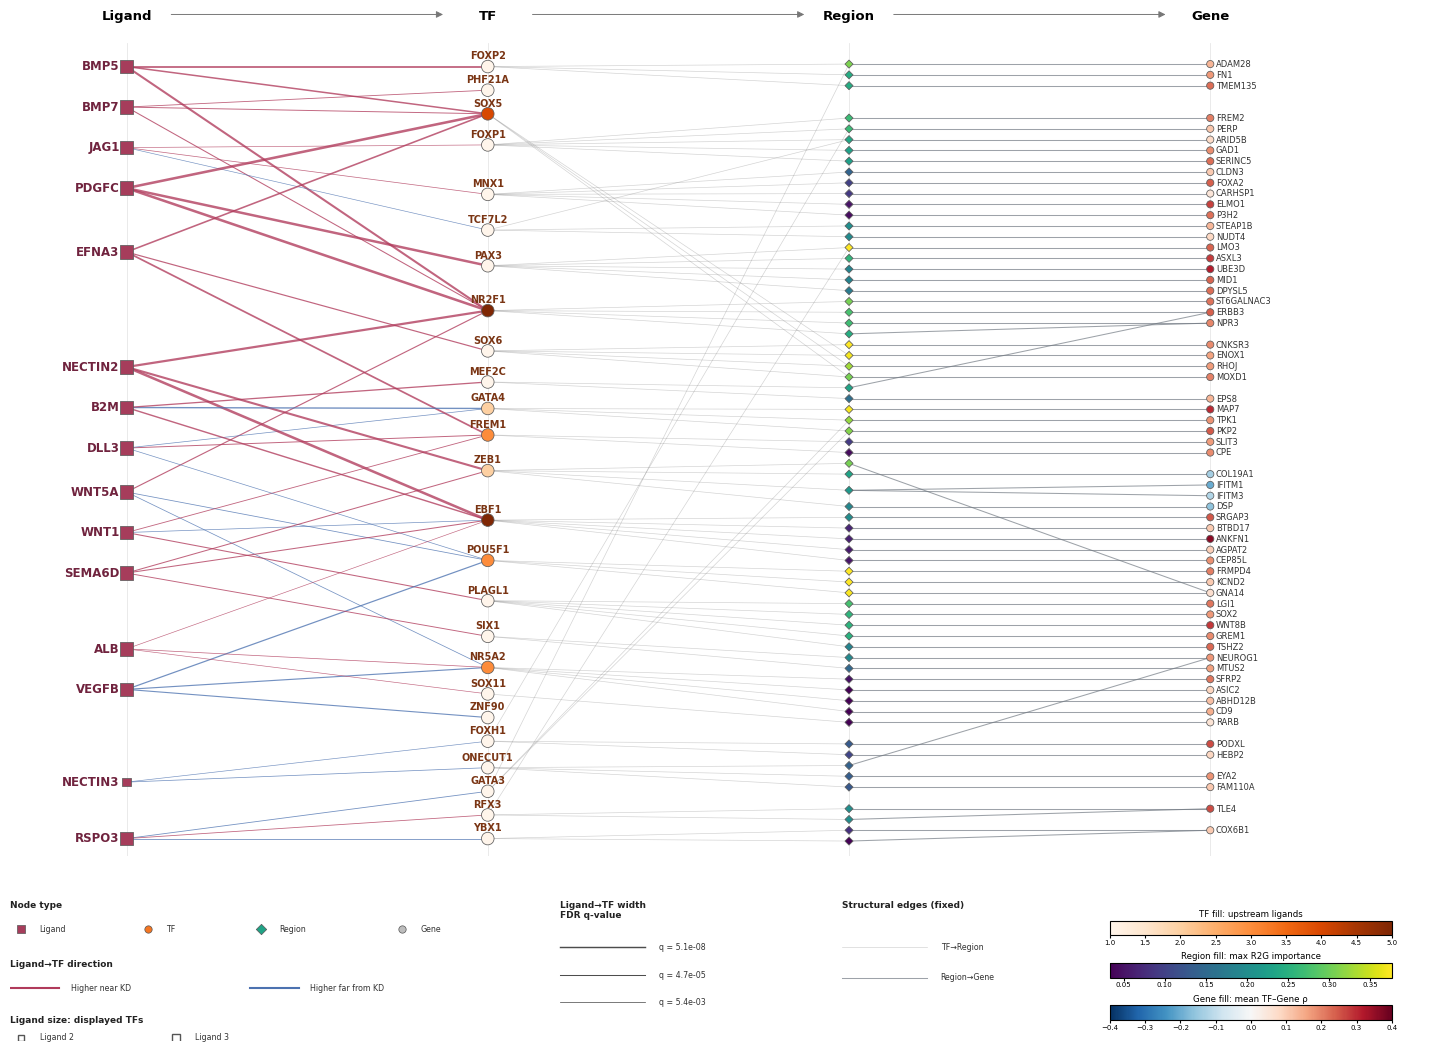

Saved publication figure to /Users/lulu/Documents/ForJavid/scplus_pipeline/plots/ligand_network_top3_per_ligand_horizontal.pdf
Saved publication figure to /Users/lulu/Documents/ForJavid/scplus_pipeline/plots/ligand_network_top3_per_ligand_horizontal.svg
Saved publication figure to /Users/lulu/Documents/ForJavid/scplus_pipeline/plots/ligand_network_top3_per_ligand_horizontal.png


In [11]:
horizontal_x_scale = 1.55
horizontal_layer_x = {
    node_type: x_value * horizontal_x_scale
    for node_type, x_value in {'Ligand': 0.0, 'TF': 1.0, 'Region': 2.0, 'Gene': 3.0}.items()
}
pos_horizontal = {
    node: (x_value * horizontal_x_scale, y_value)
    for node, (x_value, y_value) in pos_per_ligand.items()
}
assert pos_horizontal.keys() == pos_per_ligand.keys()
assert all(np.isclose(pos_horizontal[node][1], pos_per_ligand[node][1]) for node in pos_horizontal)

(
    fig, axes, styled_nodes, styled_edges, metadata
) = plot_hierarchical_network_publication(
    nodes_per_ligand, edges_per_ligand, pos_horizontal,
    figsize=(15.0, 10.5), rho_limit=0.4,
    layer_x=horizontal_layer_x, xlim=(-0.50, 5.55),
    label_regions=False,
)

assert set(styled_nodes['node']) == set(nodes_per_ligand['node'])
assert len(styled_edges) == len(edges_per_ligand)
output_base = os.path.join(
    plots_dir, 'ligand_network_top3_per_ligand_horizontal'
)
output_files = save_publication_figure(fig, output_base, dpi=300)
assert all(os.path.exists(path) for path in output_files.values())